In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt , seaborn as sns 
%matplotlib inline

In [2]:
df = pd.read_csv('study_hours_marks.csv')
df.head()

,Study_Hours,Marks
0,3.75,72.44
1,9.51,98.41
2,7.32,86.02
3,5.99,78.44
4,1.56,50.41


In [3]:
x = df[['Study_Hours']]
y = df['Marks']

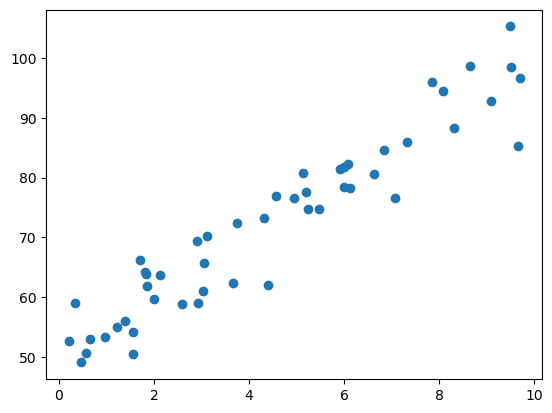

In [4]:
plt.scatter(df['Study_Hours'],df['Marks'])
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.25,random_state=42)
y_test.shape

(13,)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [7]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression(n_jobs=-1)
regression.fit(x_train,y_train)
print('Cofficent or slope',regression.coef_)
print('Intercept',regression.intercept_)


Cofficent or slope [14.2116773]
Intercept 73.13216216216216


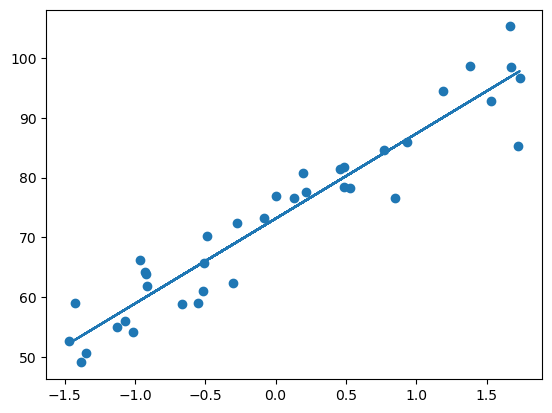

In [8]:
plt.scatter(x_train,y_train)
plt.plot(x_train, regression.predict(x_train))
plt.show()

In [9]:
y_pred = regression.predict(x_test)

In [10]:
from sklearn.metrics import mean_absolute_error , mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [11]:
print(f'MSE: {mse}\nMAE: {mae}\nRMSE {rmse}')

MSE: 22.069675235502153
MAE: 3.763995750862551
RMSE 4.69783729342579


In [12]:
from sklearn.metrics import r2_score
score = r2_score(y_test ,y_pred)

In [13]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)

0.8734170013341941

In [14]:
import statsmodels.api as sn
model = sn.OLS(y_train,x_train).fit()
predic=model.predict(x_train)
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                  Marks   R-squared (uncentered):                   0.036
Model:                            OLS   Adj. R-squared (uncentered):              0.009
Method:                 Least Squares   F-statistic:                              1.354
Date:                Sun, 26 Oct 2025   Prob (F-statistic):                       0.252
Time:                        21:07:23   Log-Likelihood:                         -211.38
No. Observations:                  37   AIC:                                      424.8
Df Residuals:                      36   BIC:                                      426.4
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [15]:
regression.predict(scaler.transform([[2.4]]))

d:\test\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([62.75960958])

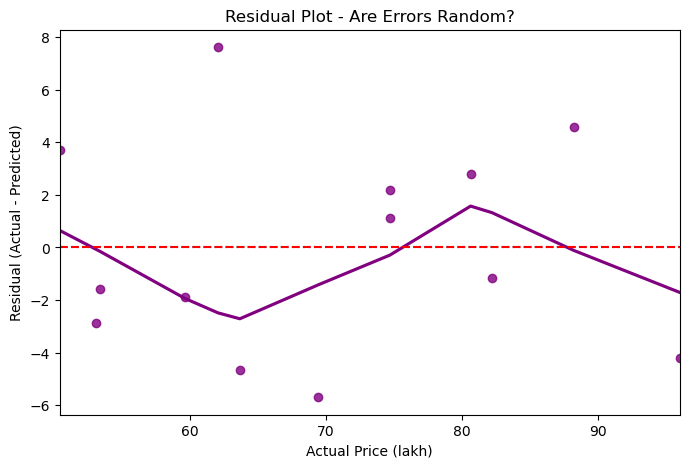

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.residplot(x=y_test, y=y_pred, lowess=True, color="purple")
plt.title("Residual Plot - Are Errors Random?")
plt.xlabel("Actual Price (lakh)")
plt.ylabel("Residual (Actual - Predicted)")
plt.axhline(0, color='red', linestyle='--')
plt.show()